### Implementation of the Perceptron Algorithm

Let's write a Perceptron class that sets initializes weights from a normal distribution with a mean of 0 and a standard deviation of 0.01, and initializes the bias to 0.

In [1]:
import numpy as np

class Perceptron:
    """Perceptron classifier.
    
    Parameters
    ------------
    eta: float
        Learning rate (between 0.0 and 1.0)
    n_iter: int
        Passes over the training dataset.
    random_state: int
        Random number generator seed for random weight initialization.

    Attributes
    -----------
    w_: 1d-array
        Weights after fitting.
    b_: Scalar
        Bias unit after fitting.
    
    errors_: list
        Number of misclassifications (updates) in every epoch.
    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """Fit training data.

        Parameters
        ------------
        X : {array-like}, shape = [n_examples, n_features]
        Training vectors, where n_examples is the number of examples 
        and n_features is the number of features.
        y : array-like, shape = [n_examples]
        Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, 
                              size=X.shape[1])
        self.b_ = np.float64(0.)
        self.errors_ = []

        for _ in range(self.n_iter):
            errors = 0
            for xi, target in zip(X, y):
                update = self.eta * (target - self.predict(xi))
                self.w_ += update * xi
                self.b_ += update
                errors += int(update != 0.0)
            self.errors_.append(errors)
        
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.net_input(X) >= 0.0, 1, 0)


Let's load the Iris dataset and print the last five lines to check that the data is loaded properly.

In [2]:
import pandas as pd

df = pd.read_csv("iris.data",
                header=None,
                encoding='utf-8')
df.tail()

,0,1,2,3,4
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Next, we extract the first 100 class labels that correspond to the 50 Iris-setosa and 50 Iris-versicolor flowers and convert the class into the two integer class labels, 1 (versicolor) and 0 (setosa). 

Similarly, we extract the first feature column (sepal length) and the third feature column (petal length) of those 100 training examples and assign them to a feature matrix, X, which we can visualize via a two-dimensional scatterplot

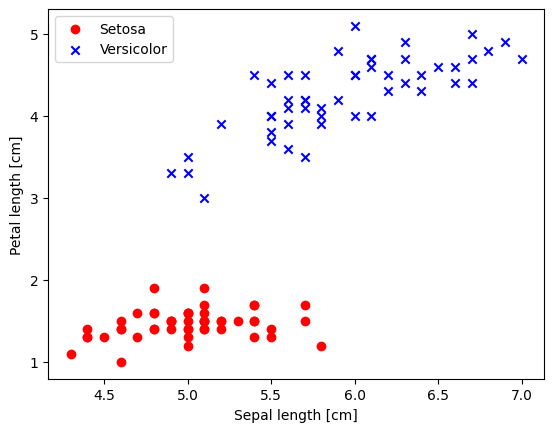

In [3]:
import matplotlib.pyplot as plt

# Select setosa and versicolor
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', 0, 1)

# Extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

# Plot the data
plt.scatter(X[:50, 0], X[:50, 1], 
            color = 'red', marker = 'o', label = 'Setosa')
plt.scatter(X[50:100, 0], X[50:100, 1],
            color = 'blue', marker = 'x', label = 'Versicolor')

plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

Now, let's train our perceptron algorithm on the Iris data subset that we just extracted. We will also plot the misclassification error for each epoch to check whether the algorithm converged and found a decision boundary that separates the two Iris flower classes:

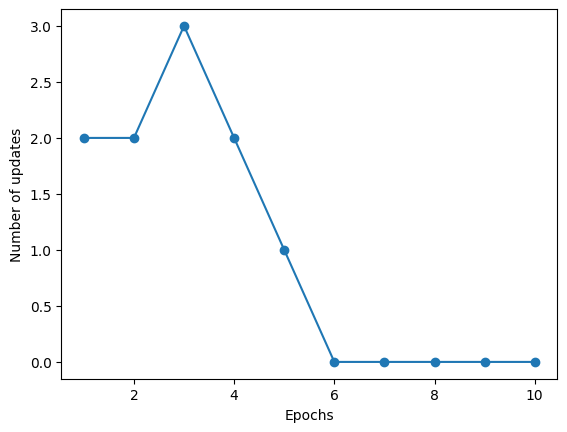

In [4]:
ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errors_) + 1),
         ppn.errors_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Number of updates')
plt.show()

Our perceptron converged after the sixth epoch and should now be able to classify the training examples perfectly. Let's implement a small convenience function to visualize the decision boundaries for two-dimensional datasets:

In [5]:
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):
    """
    Plot 2D decision regions for a trained classifier.

    Parameters
    ----------
    X : array-like of shape (n_samples, 2)
        Feature matrix with exactly 2 columns.
    y : array-like of shape (n_samples,)
        Class labels.
    classifier : object
        Trained model with a .predict() method.
    resolution : float
        Step size for the background grid.
    """

    # Visual style for each class
    markers = ('o', 's', '^', 'v', '<')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    unique_classes = np.unique(y)
    cmap = ListedColormap(colors[:len(unique_classes)])

    # Determine plot boundaries from the data
    x_min = X[:, 0].min() - 1
    x_max = X[:, 0].max() + 1
    y_min = X[:, 1].min() - 1
    y_max = X[:, 1].max() + 1

    # Create a dense grid of coordinates covering the whole plot area
    x_values = np.arange(x_min, x_max, resolution)
    y_values = np.arange(y_min, y_max, resolution)
    grid_x, grid_y = np.meshgrid(x_values, y_values)

    # Convert the grid into a list of points:
    # [[x1, y1], [x2, y2], [x3, y3], ...]
    grid_points = np.column_stack((grid_x.ravel(), grid_y.ravel()))

    # Predict a class for every point in the grid
    grid_predictions = classifier.predict(grid_points)

    # Turn the 1D predictions back into the 2D grid shape
    decision_map = grid_predictions.reshape(grid_x.shape)

    # Draw the colored decision regions
    plt.contourf(grid_x, grid_y, decision_map, alpha=0.3, cmap=cmap)
    plt.xlim(grid_x.min(), grid_x.max())
    plt.ylim(grid_y.min(), grid_y.max())

    # Plot the actual data points on top
    for class_index, class_label in enumerate(unique_classes):
        plt.scatter(
            X[y == class_label, 0],
            X[y == class_label, 1],
            alpha=0.8,
            c=colors[class_index],
            marker=markers[class_index],
            label=f"Class {class_label}",
            edgecolor="black"
        )


First, we define a number of colors and markers and create a colormap from the list of colors via ListedColormap. Then, we determine the minimumn and the maximum values for the two features and use those feature vectors to create a pair of grid arrays, xx1 and xx2, via meshgrid function. Since we trained our perceptron classifier on two feature dimensions, we need to flatten the grid arrays and create a matrix that has the same number of columns as the Iris training subset so that we can use the predict method to predict the class labels, lab, of the corresponding grid points.

After reshaping the predicted class labels, lab, into a grid with the same dimensions as xx1 and xx2, we can now draw a contour plot via Matplotlib's contourf function, which maps the different decision regions to different colors for each predicted class in the grid array:

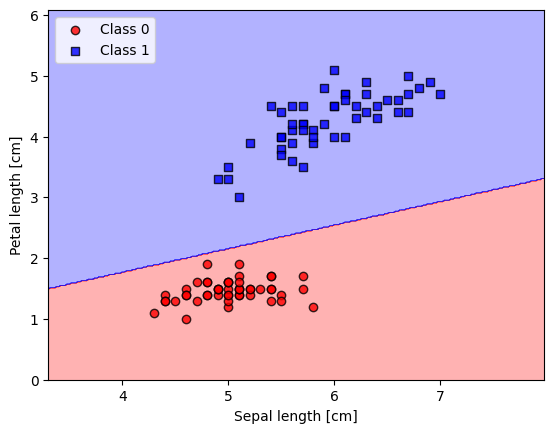

In [6]:
plot_decision_regions(X, y, classifier=ppn)
plt.xlabel('Sepal length [cm]')
plt.ylabel('Petal length [cm]')
plt.legend(loc='upper left')
plt.show()

### Adaptive Linear Neurons and the Convergence of Learning

Another type of single-layer neural network is Adaptive Linear Neuron (Adaline). This algorithm is particularly interesting because it illustrates the key concepts of defining and minimizing continuous loss functions, which lays the groundwork for understanding other machine learning algorithms for classification, such as logistic regression, support vector machines, and multilayer neural networks. 

The key difference between Adaline and perceptron is that the weights are updated based on a linear activation function rather than a unit step function like in the perceptron. In Adaline, this linear activation function is the identity function of the net input.

While the linear activation function is used for learning the weights, we still use a threshold function to make the final prediction, which is similar to the unit step function.

Since the perceptron and Adaline are very similar, we can take the previous perceptron implementation and change the fit method so that the weight and bias parameters are now updated by minimizing the loss function via gradient descent:

In [7]:
class AdalineGD:
    """ADAptive LInear NEuron classifier.

    Parameters
    ----------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
    random_state : int
        Random number seed for weight initialization.

    Attributes
    ----------
    w_ : 1d-array
        Weights after fitting.
    b_ : Scalar
        Bias unit after fitting.
    losses_ : list
        Mean squared error loss function value in each epoch.
    """ 

    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state
    
    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_examples, n_features]
            Training vectors, where n_examples is the number of samples and
            n_features is the number of features.
        y : array-like, shape = [n_examples]
            Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, 
                              size=X.shape[1])
        self.b_ = np.float64(0.0)
        self.losses_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_ += self.eta * 2 * X.T.dot(errors) / X.shape[0]
            self.b_ += self.eta * 2 * errors.mean()
            loss = (errors**2).mean()
            self.losses_.append(loss)
        
        return self
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_
    
    def activation(self, X):
        """Compute linear activation"""
        return X
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)


Let's plot the loss against the number of epochs for two different learning rates:

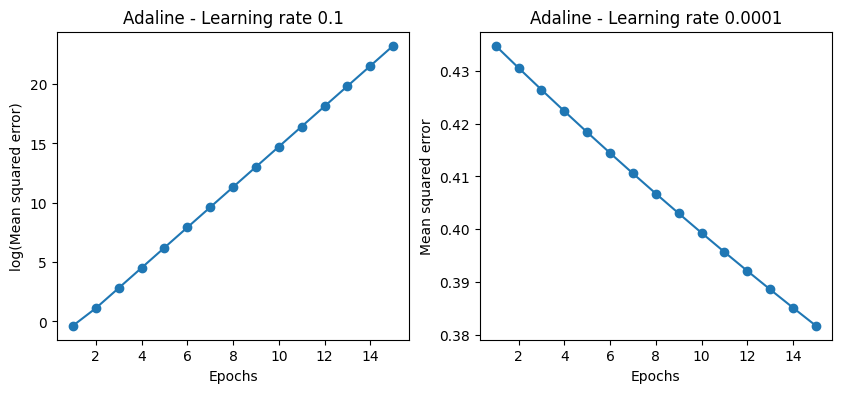

In [8]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
ada1 = AdalineGD(eta=0.1, n_iter=15).fit(X, y)
ax[0].plot(range(1, len(ada1.losses_) + 1), 
           np.log10(ada1.losses_), marker='o')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('log(Mean squared error)')
ax[0].set_title('Adaline - Learning rate 0.1')

ada2 = AdalineGD(eta=0.0001, n_iter=15).fit(X, y)
ax[1].plot(range(1, len(ada2.losses_) + 1),
           ada2.losses_, marker='o')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Mean squared error')
ax[1].set_title('Adaline - Learning rate 0.0001')
plt.show()

As we can see, choosing a learning rate that is too large causes MSE to become larger in every epoch, because we overshoot the global minimum. On the other hand, choosing a learning rate too small requires a large number of epochs to converge to the global loss minimum.

Let's standardize the data and train Adaline again and see how fast it converges now:

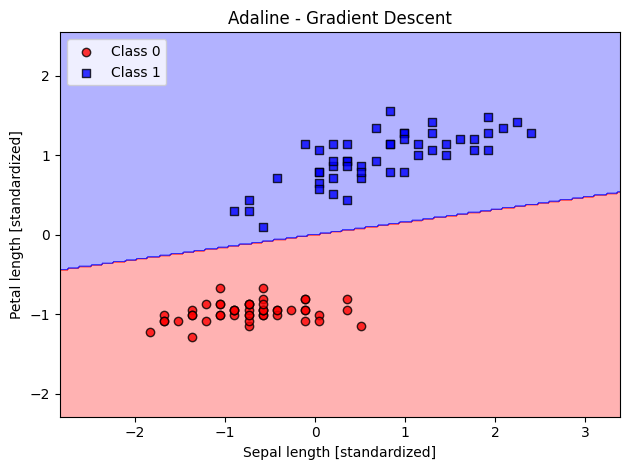

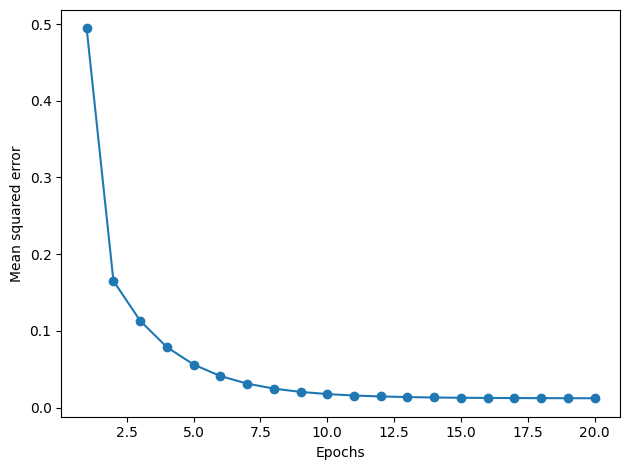

In [9]:
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

ada_gd = AdalineGD(eta=0.5, n_iter=20)
ada_gd.fit(X_std, y)

plot_decision_regions(X_std, y, classifier=ada_gd)
plt.title('Adaline - Gradient Descent')
plt.xlabel('Sepal length [standardized]')
plt.ylabel('Petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
plt.plot(range(1, len(ada_gd.losses_) + 1), 
         ada_gd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Mean squared error')
plt.tight_layout()
plt.show()

Now, let's implement Adaline using Stochastic Gradient Descent (SGD). Inside the fit method, we will update the weights after each training example. We will also implement a partial_fit method, which does not reinitialize the weights, for online learning. Lastly, we will add an option to shuffle the training data before each epoch to avoid repetitive cycles when we are optimizing for the loss function:

In [10]:
class AdalineSGD:
    """ADAptive LInear NEuron classifier.
    
    Parameters
    ----------
    eta: float
        Learning rate (between 0.0 and 1.0)
    n_iter: int
        Number of passes over the training dataset.
    shuffle: bool (default: True)
        Whether to shuffle the training data every epoch to prevent cycles.
    random_state: int (default: None)
        Random number generator seed for random weight initialization.
    
    Attributes
    ----------
    w_: 1d-array
        Weights after fitting.
    b_: Scalar
        Bias unit after fitting.
    losses_: list
        Mean squared error loss function value averaged over all
        training examples in each epoch.

    """

    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state
    
    def fit(self, X, y):
        """Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like, shape = [n_samples]
            Target values.

        Returns
        -------
        self : object
        """
        self._initialize_weights(X.shape[1])
        self.losses_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            losses = []
            for xi, target in zip(X, y):
                losses.append(self._update_weights(xi, target))
            avg_loss = np.mean(losses)
            self.losses_.append(avg_loss)
        return self

    
    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""

        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        
        return self
    
    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]
    
    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, 
                                   size=m)
        self.b_ = np.float64(0.)
        self.w_initialized = True

    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = target - output
        self.w_ += self.eta * xi * error
        self.b_ += self.eta * error
        loss = error ** 2
        return loss
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_) + self.b_
    
    def activation(self, X):
        """Computer linear activation"""
        return X
    
    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.5, 1, 0)
        

We can now use the fit method to train our AdalineSGD classifier and use the plot_decision_regions to plot the training results:

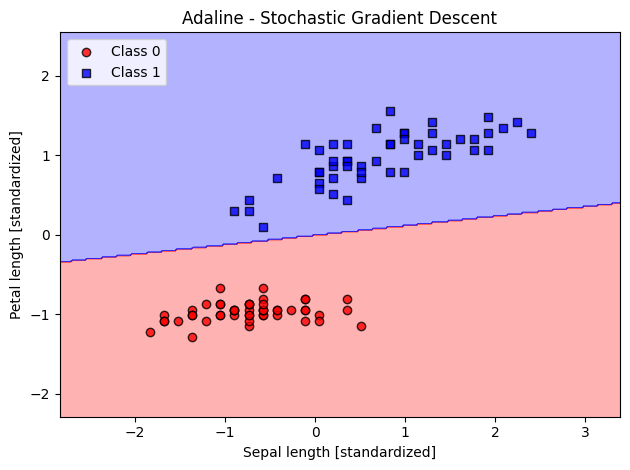

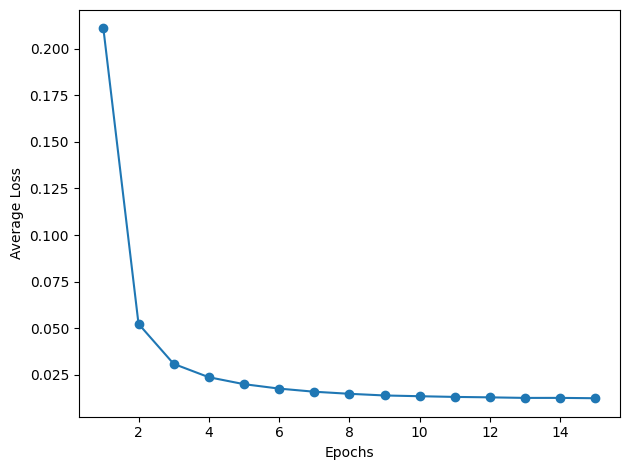

In [11]:
ada_sgd = AdalineSGD(eta=0.01, n_iter=15, random_state=1)
ada_sgd.fit(X_std, y)
plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title("Adaline - Stochastic Gradient Descent")
plt.xlabel("Sepal length [standardized]")
plt.ylabel("Petal length [standardized]")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
plt.plot(range(1, len(ada_sgd.losses_) + 1), ada_sgd.losses_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average Loss')
plt.tight_layout()
plt.show()